In [2]:
pip install tensorflow

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 9.3 MB/s  0:00:23m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 8.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━

In [2]:
# this is only for macos like mine 
!pip install tensorflow-macos

  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 MB 11.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 8.2 MB/s eta 0:00:00a 0:00:01m
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.2
    Uninstalling protobuf-6.33.2:
      Successfully uninstalled protobuf-6.33.2
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.4
    Uninstalling ml_dtypes-0.5.4:
      Successfully uninstalled ml_dtypes-0.5.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.39.1 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.


In [1]:
pip install PIL

ERROR: Could not find a version that satisfies the requirement PIL (from versions: none)
ERROR: No matching distribution found for PIL
Note: you may need to restart the kernel to use updated packages.


In [11]:
import os 
import numpy as np 
import tensorflow as tf 
from PIL import Image 
import matplotlib.pyplot as plt 

In [ ]:
MODEL_PATH = "/Users/fokia/CentraleSupelec-CV-and-RL-project/emonext_best.keras" 
FILTERED_FRAMES = "/Users/fokia/CentraleSupelec-CV-and-RL-project/filtered_frames" 
IMG_SIZE = (48,48) 

# Since we grouped by 3 classes , adjust the labels 
# the standard FER model 7 classes
CLASS_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
# but we dont care about this diff that much, we would rather have 3 types of mapping, which is shown here : 
emotion_mapper = {
    'Angry':    'Positive', #its a good sign, when someone looks angry it means they are "locked in" 
                            # or very very very very very high 
    'Disgust':  'Neutral',  # oof I am not sure about htis class, change it to neutral instead 
    'Fear':     'Negative',
    'Sad':      'Negative',
    
    'Happy':    'Positive',
    'Surprise': 'Positive',
    
    'Neutral':  'Neutral' 
}


In [ ]:
import tensorflow as tf
import keras
from tensorflow.keras import layers

#  Custom class 1: StochasticDepth 
@keras.saving.register_keras_serializable()
class StochasticDepth(tf.keras.layers.Layer):
    def __init__(self, drop_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.drop_rate = drop_rate

    def call(self, x, training=None):
        if not training or self.drop_rate == 0:
            return x
        survival = 1.0 - self.drop_rate
        batch_size = tf.shape(x)[0]
        noise = tf.random.uniform((batch_size, 1, 1, 1), dtype=tf.float32)
        mask = tf.cast(noise < survival, x.dtype)
        return x * mask / tf.cast(survival, x.dtype)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"drop_rate": self.drop_rate})
        return cfg

#  Custom class 2: STN (Spatial Transformer Network) 
@keras.saving.register_keras_serializable()
class STN(tf.keras.layers.Layer):
    def build(self, input_shape):
        self.loc_conv1   = layers.Conv2D(32, 5, padding='same', activation='relu')
        self.loc_pool1   = layers.MaxPooling2D(2)
        self.loc_conv2   = layers.Conv2D(64, 3, padding='same', activation='relu')
        self.loc_pool2   = layers.MaxPooling2D(2)
        self.loc_flatten = layers.Flatten()
        self.loc_fc1     = layers.Dense(128, activation='relu')
        self.loc_fc2     = layers.Dense(
            6,
            kernel_initializer='zeros',
            bias_initializer=tf.keras.initializers.Constant([1, 0, 0, 0, 1, 0]),
            dtype='float32'
        )
        super().build(input_shape)

    def call(self, x):
        B    = tf.shape(x)[0]
        H, W = x.shape[1], x.shape[2]
        x_f32 = tf.cast(x, tf.float32)
        loc  = self.loc_pool1(self.loc_conv1(x_f32))
        loc  = self.loc_pool2(self.loc_conv2(loc))
        theta = self.loc_fc2(self.loc_fc1(self.loc_flatten(loc)))
        theta = tf.reshape(theta, [B, 2, 3])
        x_lin = tf.linspace(-1.0, 1.0, W)
        y_lin = tf.linspace(-1.0, 1.0, H)
        xg, yg = tf.meshgrid(x_lin, y_lin)
        ones = tf.ones_like(xg)
        grid = tf.reshape(tf.stack([xg, yg, ones], axis=-1), [-1, 3])
        grid = tf.tile(tf.expand_dims(grid, 0), [B, 1, 1])
        grid = tf.matmul(grid, tf.transpose(theta, [0, 2, 1]))
        grid = tf.reshape(grid, [B, H, W, 2])
        return self._bilinear_sample(x_f32, grid, H, W)

    def _bilinear_sample(self, img, grid, H, W):
        B = tf.shape(img)[0]
        gx = (grid[..., 0] + 1.0) * tf.cast(W - 1, tf.float32) / 2.0
        gy = (grid[..., 1] + 1.0) * tf.cast(H - 1, tf.float32) / 2.0
        x0, y0 = tf.cast(tf.floor(gx), tf.int32), tf.cast(tf.floor(gy), tf.int32)
        x1, y1 = x0 + 1, y0 + 1
        x0 = tf.clip_by_value(x0, 0, W-1); x1 = tf.clip_by_value(x1, 0, W-1)
        y0 = tf.clip_by_value(y0, 0, H-1); y1 = tf.clip_by_value(y1, 0, H-1)
        b = tf.tile(tf.reshape(tf.range(B), [B, 1, 1]), [1, H, W])
        def gather(y, x):
            return tf.gather_nd(img, tf.stack([b, y, x], axis=-1))
        wa = tf.expand_dims((tf.cast(x1, tf.float32)-gx)*(tf.cast(y1, tf.float32)-gy), -1)
        wb = tf.expand_dims((tf.cast(x1, tf.float32)-gx)*(gy-tf.cast(y0, tf.float32)), -1)
        wc = tf.expand_dims((gx-tf.cast(x0, tf.float32))*(tf.cast(y1, tf.float32)-gy), -1)
        wd = tf.expand_dims((gx-tf.cast(x0, tf.float32))*(gy-tf.cast(y0, tf.float32)), -1)
        return wa*gather(y0,x0) + wb*gather(y1,x0) + wc*gather(y0,x1) + wd*gather(y1,x1)

    def get_config(self):
        return super().get_config()

#  Load model 
model = tf.keras.models.load_model(
    "/Users/fokia/CentraleSupelec-CV-and-RL-project/emonext_best.keras",
    custom_objects={"STN": STN, "StochasticDepth": StochasticDepth}
)
print("Model loaded ✓")


Model loaded ✓


/opt/anaconda3/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 269 variables whereas the saved optimizer has 273 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [5]:
print("Model loaded ✓")
model.summary()


Model loaded ✓


Model: "EmoNeXt"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 48, 48, 1) │          0 │ input_layer_8[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stn_5 (STN)         │ (None, 48, 48, 1) │  1,199,878 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 12, 12,    │      1,088 │ stn_5[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 12,    │        128 │ conv2d_25[0][0]   │
│ (LayerNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_19 │ (None, 12, 12,    │      3,200 │ layer_normalizat… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 12,    │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_82 (Dense)    │ (None, 12, 12,    │     16,640 │ layer_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 12, 12,    │          0 │ dense_82[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_83 (Dense)    │ (None, 12, 12,    │     16,448 │ activation_19[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1, 64)  │          0 │ dense_83[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_84 (Dense)    │ (None, 1, 1, 4)   │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_85 (Dense)    │ (None, 1, 1, 64)  │        320 │ dense_84[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_12         │ (None, 12, 12,    │          0 │ dense_83[0][0],   │
│ (Multiply)          │ 64)               │            │ dense_85[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stochastic_depth_9  │ (None, 12, 12,    │          0 │ multiply_12[0][0] │
│ (StochasticDepth)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 12, 12,    │          0 │ stochastic_depth… │
│                     │ 64)               │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_20 │ (None, 12, 12,    │      3,200 │ add_18[0][0]      │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 12,    │        128 │ depthwise_conv2d

 Total params: 10,824,673 (41.29 MB)

 Trainable params: 3,608,224 (13.76 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,216,449 (27.53 MB)

In [8]:
!pip install opencv-python


  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 10.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.3 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.3 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.3 which is incompatible.
tensorflow 2.16.2 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy

In [11]:
!pip install "numpy<2" --force-reinstall


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 8.1 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [13]:
# we NEED to find all of the faces first from each frame
# RREADME : ok , a fun exercise but its not that good :( and its almost the same age as me 
# I will instead use a deep learning pretrained 
def predict_frame_optimized(img_path, model, class_labels, img_size = (48,48)): 
    frame = cv2.imread(img_path) 
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # first lets find all the faces: 
    # grayscale it 
    bboxes = face_cascade.detectMultiScale(gray, scaleFactor = 1.1,minNeighbors = 2 , minSize = (30,30)) 

    # no faces, but should not have this scenario as we have filtered them 
    if len(bboxes) == 0: 
        return None 
    faces_cut = []
    for (x,y,w,h) in bboxes: 
        face = gray[y:y+h, x:x+w] 
        face = cv2.resize(face, img_size).astype(np.float32) / 255.0 
        face = face[..., np.newaxis] # add channel 
        faces_cut.append(face) 
    # the list faces_cut will be converted into a single block of shape(num_faces,48,48,1) 
    face_block = np.array(faces_cut) 

    # step 2: categorize 
    results = [] 

    #parse all the face batches into the model at once 
    prediction = model.predict(face_block,verbose = 0)

    # map the prediction back to the bounding box and labels 
    for i,p in enumerate(prediction): 
        bbox = bboxes[i] 
        original_label = class_labels[np.argmax(p)] 
        # our mapping
        label = emotion_mapper[original_label]
        label= class_labels[np.argmax(p)]

        results.append({"probs": p.tolist(), 
                        "label": label, 
                        "bbox" : (bbox[0],bbox[1],bbox[2],bbox[3])})
    return results 


NameError: name 'p' is not defined

In [47]:
# Make sure to put the actual path to one of your frames here!
test_frame_path = "filtered_frames/Marlon Hoffstadt  Boiler Room Melbourne - Boiler Room (720p, h264)/frame_000660.jpg"

output = predict_frame_optimized(test_frame_path, model, CLASS_LABELS)

print("Faces Detected:", output)


Faces Detected: [{'probs': [0.14096595346927643, 0.2312854379415512, 0.16484998166561127, 0.11989802122116089, 0.28636521100997925, 0.056635476648807526], 'label': 'Sad', 'bbox': (1060, 271, 56, 56)}, {'probs': [0.10188668966293335, 0.04607683792710304, 0.059186965227127075, 0.6822205185890198, 0.08679008483886719, 0.023838860914111137], 'label': 'Happy', 'bbox': (730, 173, 72, 72)}]


Faces Detected: [{'probs': [0.36639782786369324, 0.22569362819194794, 0.16245780885219574, 0.10556454211473465, 0.10717999935150146, 0.032706260681152344], 'label': 'Angry', 'bbox': (825, 76, 127, 127)}, {'probs': [0.4472353756427765, 0.10122944414615631, 0.2299140840768814, 0.11085545271635056, 0.05538395047187805, 0.05538162589073181], 'label': 'Angry', 'bbox': (258, 115, 77, 77)}, {'probs': [0.17294394969940186, 0.48012447357177734, 0.20872418582439423, 0.03563867136836052, 0.04175673425197601, 0.06081204488873482], 'label': 'Disgust', 'bbox': (938, 277, 172, 172)}, {'probs': [0.293390691280365, 0.1418009251356125, 0.152250275015831, 0.14420686662197113, 0.17613953351974487, 0.09221160411834717], 'label': 'Angry', 'bbox': (713, 466, 79, 79)}, {'probs': [0.17364969849586487, 0.413076788187027, 0.1470658928155899, 0.04485228657722473, 0.16113466024398804, 0.06022074073553085], 'label': 'Disgust', 'bbox': (978, 334, 55, 55)}]


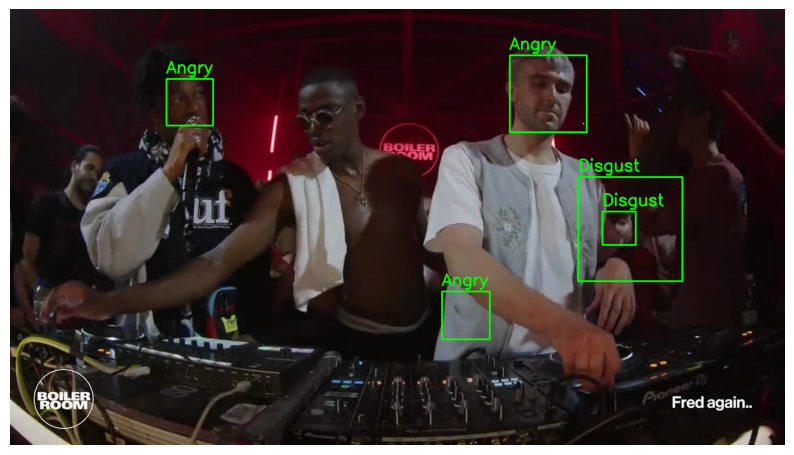

In [76]:
# Make sure to put the actual path to one of your frames here!
test_frame_path = "filtered_frames/Fred again.. ｜ Boiler Room： London/frame_000036.jpg"

output = predict_frame_optimized(test_frame_path, model, CLASS_LABELS)

print("Faces Detected:", output)

# Grab the original color image
display_frame = cv2.imread(test_frame_path)

# Draw the boxes and labels directly onto the image
if output:
    for r in output:
        x, y, w, h = r['bbox']
        label = r['label']
        
        # 1. Draw a bright green bounding box around the face
        cv2.rectangle(display_frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # 2. Write the predicted emotion physically above the box
        cv2.putText(display_frame, label, (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# OpenCV uses BGR colors, but Matplotlib exactly expects RGB, so we swap them!
display_frame_rgb = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)

# Display the final masterpiece right here in the notebook
plt.figure(figsize=(10, 8))
plt.imshow(display_frame_rgb)
plt.axis('off') # Hides the ugly graph axes
plt.show()


In [58]:
# RREADME : ok , a fun exercise but its not that good :( and its almost the same age as me 
# I will instead use a deep learning pretrained 
# Instead I will use MTCNN , easy  and very accurate apparently 
!pip install mtcnn


In [14]:
import cv2
import numpy as np 
from mtcnn import MTCNN

# Initialize dl detector
detector = MTCNN() # because their faces are def smaller than the default 20x20

def predict_frame_optimized_mtcnn(img_path, model, class_labels, img_size=(48, 48)): 
    # Load the image
    frame = cv2.imread(img_path) 
    
    # Safety Check: If OpenCV literally cannot find the file
    if frame is None:
        print(f"Error: OpenCV could not find a valid image at '{img_path}'")
        return None
        
    # MTCNN loves standard RGB colors, so we convert it!
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # We still need a grayscale version because your emotion model expects it
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # ==========================================
    # 1. IDENTIFY THE FACES (WITH MTCNN)
    # ==========================================
    try:
        faces_data = detector.detect_faces(rgb_frame)
    except ValueError:
        #"""# Process images through each stage (PNet, RNet, ONet)
        #    158     for stage in self.stages:
        #--> 159         bboxes_batch = stage(bboxes_batch=bboxes_batch, images_normalized=images_normalized, images_oshapes=images_oshapes, **kwargs)
        #    161 except tf.errors.InvalidArgumentError:  # No faces found
        #    162     bboxes_batch = np.empty((0, 16))
        #    """ annoying bug due to diff versions of tensorflow and mtcnn 
        return None

    # Extract the bounding boxes for any face MTCNN is at least 90% sure about
    bboxes = []
    for f in faces_data:
        if f['confidence'] > 0.30:  # reduced to test 
            x, y, w, h = f['box']
            # Prevent perfectly negative coordinates from crashing OpenCV
            x, y = abs(x), abs(y) 
            bboxes.append((x, y, w, h))

    if len(bboxes) == 0: 
        return None 
        
    faces_cut = []
    for (x, y, w, h) in bboxes: 
        # Crop the face out of the GRAYSCALE image 
        face = gray[y:y+h, x:x+w] 
        
        # Extra Armor: If the face was too far off-screen to crop, skip it!
        if face.size == 0:
            continue
            
        face = cv2.resize(face, img_size).astype(np.float32) / 255.0 
        face = face[..., np.newaxis] 
        faces_cut.append(face) 
        
    if len(faces_cut) == 0:
        return None
        
    # Combine individual faces into a single fast batch
    face_block = np.array(faces_cut) 
    
    # ==========================================
    # 2. CATEGORIZE THE FACES
    # ==========================================
    if len(face_block) == 0:
        return None
    results = [] 
    
    try:
    # Predict the entire batch of faces at once (lightning fast!)
        predictions = model.predict(face_block, verbose=0)
    except Exception as e: 
        print(f"Skipping: {e}")
        return None 

    # Map the predictions back onto their original bounding boxes
    for i, p in enumerate(predictions): 
        bbox = bboxes[i] 
        
        # (Remember: If your model outputs 7 probabilities but you only want 3 labels, 
        # you need to use the emotion_mapper trick here instead of class_labels directly!)
        label = class_labels[np.argmax(p)]

        results.append({
            "probs": p.tolist(), 
            "label": label, 
            "bbox" : (bbox[0], bbox[1], bbox[2], bbox[3]),
            "img_path": img_path 
        })
        
    return results 


Faces Detected: [{'probs': [0.2246546596288681, 0.27697888016700745, 0.15310299396514893, 0.19399166107177734, 0.11824864149093628, 0.0330231674015522], 'label': 'Disgust', 'bbox': (828, 83, 94, 121), 'img_path': 'filtered_frames/Fred again.. ｜ Boiler Room： London/frame_000036.jpg'}, {'probs': [0.03598727285861969, 0.07939349114894867, 0.02579839900135994, 0.8200375437736511, 0.017388850450515747, 0.021394450217485428], 'label': 'Happy', 'bbox': (111, 243, 43, 54), 'img_path': 'filtered_frames/Fred again.. ｜ Boiler Room： London/frame_000036.jpg'}, {'probs': [0.09380143135786057, 0.1165195181965828, 0.08886431157588959, 0.5580255389213562, 0.12377683818340302, 0.019012343138456345], 'label': 'Happy', 'bbox': (245, 109, 77, 100), 'img_path': 'filtered_frames/Fred again.. ｜ Boiler Room： London/frame_000036.jpg'}, {'probs': [0.3211824595928192, 0.2521262764930725, 0.11042935401201248, 0.08339763432741165, 0.1926569938659668, 0.04020719602704048], 'label': 'Angry', 'bbox': (477, 125, 96, 12

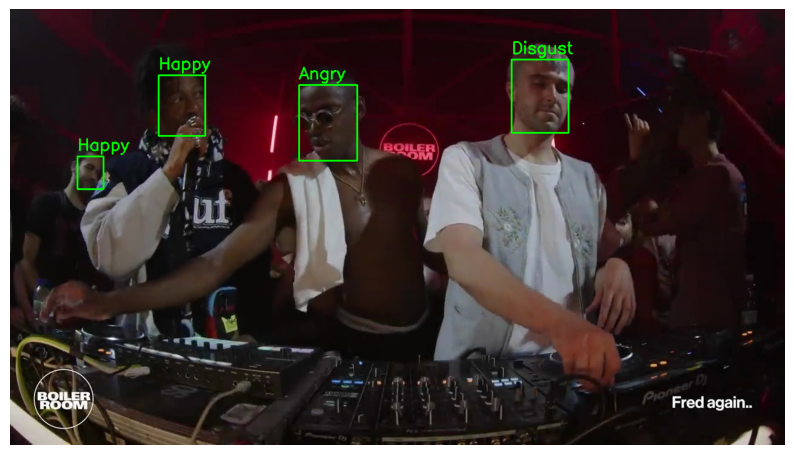

In [94]:
# Make sure to put the actual path to one of your frames here!
test_frame_path = "filtered_frames/Fred again.. ｜ Boiler Room： London/frame_000036.jpg"

output = predict_frame_optimized_mtcnn(test_frame_path, model, CLASS_LABELS)

print("Faces Detected:", output)

# Grab the original color image
display_frame = cv2.imread(test_frame_path)

# Draw the boxes and labels directly onto the image
if output:
    for r in output:
        x, y, w, h = r['bbox']
        label = r['label']
        
        # 1. Draw a bright green bounding box around the face
        cv2.rectangle(display_frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # 2. Write the predicted emotion physically above the box
        cv2.putText(display_frame, label, (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# OpenCV uses BGR colors, but Matplotlib exactly expects RGB, so we swap them!
display_frame_rgb = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)

# Display the final masterpiece right here in the notebook
plt.figure(figsize=(10, 8))
plt.imshow(display_frame_rgb)
plt.axis('off') # Hides the ugly graph axes
plt.show()


In [19]:
# ok great it is acceptable, now we will create a metric that we will feed on the reward function to 
# get some feedback for each step for our agent
# how? good news, the filtered_frames number on each of the .jpg is the seconds 
# we need to simply multi join on each of the sets to the timestamps and get a metric per step 
# first sum or something the frame metrics into each correspondent song interval

# first lets iterate from all filtered frames and store it , and then lets make a dataframe ;D
import pandas as pd 
import re 
import os 
import json 
import json, os

filtered_frames_dir = "/Users/fokia/CentraleSupelec-CV-and-RL-project/filtered_frames"
output_path = "all_facial_metrics.jsonl"  # one record per line

count = 0

with open(output_path, "w") as f:  # open the file once and write every loop
    for dj_folder in sorted(os.listdir(filtered_frames_dir)): 
        dj_path = os.path.join(filtered_frames_dir, dj_folder) 
        if not os.path.isdir(dj_path):
            continue 
        print(f"\nProcessing folder: {dj_folder}")

        for frame in sorted(os.listdir(dj_path)):
            if not frame.endswith(".jpg"):
                continue 
            frame_path = os.path.join(dj_path, frame)

            try:
                res = predict_frame_optimized_mtcnn(frame_path, model, CLASS_LABELS)
            except ValueError:
                res = None

            if res is not None:
                for face in res:
                    face["dj"] = dj_folder
                    face["img_path"] = frame_path
                    f.write(json.dumps(face) + "\n")  # write immediatly, one line per face
                    count += 1
            else:
                record = {"dj": dj_folder, "img_path": frame_path, "label": None, "probs": None, "bbox": None}
                f.write(json.dumps(record) + "\n")  
                count += 1

print(f"Done! Saved {count} entries to {output_path}")



# README: MEMORY REF BUG AS WELL 


"""# Process images through each stage (PNet, RNet, ONet)
    158     for stage in self.stages:
--> 159         bboxes_batch = stage(bboxes_batch=bboxes_batch, images_normalized=images_normalized, images_oshapes=images_oshapes, **kwargs)
    161 except tf.errors.InvalidArgumentError:  # No faces found
    162     bboxes_batch = np.empty((0, 16))
    """ # most annoying bug, compartibility issue between Tensorflow and mtcnn, TensorFlow doesnt throw a argument error, but a value



Processing folder: ALISHA Groovy Tech-House DJ Set Live From DJ Mag HQ - DJ Mag (720p, h264, youtube)

Processing folder: AZYR  Boiler Room x Teletech Festival 2023 - Boiler Room (720p, h264)

Processing folder: Chase & Status  Boiler Room London - Boiler Room (720p, h264)

Processing folder: Estella Boersma  Boiler Room Festival Berlin - Boiler Room (720p, h264, youtube)

Processing folder: Fred again.. ｜ Boiler Room： London

Processing folder: Funky Disco & House Mix Inside a Circus  Felix da Housecat - Book Club Radio (720p, h264, youtube)

Processing folder: KETTAMA  Boiler Room London - Boiler Room (720p, h264)

Processing folder: Marlon Hoffstadt  Boiler Room Melbourne - Boiler Room (720p, h264)

Processing folder: Minna-no-kimochi (みんなのきもち)  Boiler Room Tokyo Tohji Presents u-ha - Boiler Room (720p, h264)

Processing folder: Peggy Gou  Boiler Room x Dekmantel Festival Amsterdam - Boiler Room (720p, h264, youtube)

Processing folder: Yaeji  Boiler Room New York - Boiler Room (72

'# Process images through each stage (PNet, RNet, ONet)\n    158     for stage in self.stages:\n--> 159         bboxes_batch = stage(bboxes_batch=bboxes_batch, images_normalized=images_normalized, images_oshapes=images_oshapes, **kwargs)\n    161 except tf.errors.InvalidArgumentError:  # No faces found\n    162     bboxes_batch = np.empty((0, 16))\n    '

In [ ]:
import pandas as pd 
frames_df = pd.read_json("all_facial_metrics.json")  

In [ ]:
heuristic = (Avg Happy Prob + Avg Surprise Prob) - (Avg Sad Prob + Avg Neutral Prob)

,probs,label,bbox,img_path,dj
0,"[0.32118245959281905, 0.252126276493072, 0.110...",Angry,"[477, 125, 96, 125]",filtered_frames/Fred again.. ｜ Boiler Room： Lo...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...
1,"[0.32118245959281905, 0.252126276493072, 0.110...",Angry,"[477, 125, 96, 125]",filtered_frames/Fred again.. ｜ Boiler Room： Lo...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...
2,"[0.32118245959281905, 0.252126276493072, 0.110...",Angry,"[477, 125, 96, 125]",filtered_frames/Fred again.. ｜ Boiler Room： Lo...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...
3,"[0.32118245959281905, 0.252126276493072, 0.110...",Angry,"[477, 125, 96, 125]",filtered_frames/Fred again.. ｜ Boiler Room： Lo...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...
4,"[0.32118245959281905, 0.252126276493072, 0.110...",Angry,"[477, 125, 96, 125]",filtered_frames/Fred again.. ｜ Boiler Room： Lo...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...
...,...,...,...,...,...
33864,"[0.32118245959281905, 0.252126276493072, 0.110...",Angry,"[477, 125, 96, 125]",filtered_frames/Fred again.. ｜ Boiler Room： Lo...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...
33865,"[0.32118245959281905, 0.252126276493072, 0.110...",Angry,"[477, 125, 96, 125]",filtered_frames/Fred again.. ｜ Boiler Room： Lo...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...
33866,"[0.32118245959281905, 0.252126276493072, 0.110...",Angry,"[477, 125, 96, 125]",filtered_frames/Fred again.. ｜ Boiler Room： Lo...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...
33867,"[0.32118245959281905, 0.252126276493072, 0.110...",Angry,"[477, 125, 96, 125]",filtered_frames/Fred again.. ｜ Boiler Room： Lo...,¥ØUUK€ ¥UK1MATU Boiler Room Tokyo - Boiler Ro...


In [18]:
dj_sets = sorted(os.listdir(FILTERED_FRAMES))
print("DJ sets:", dj_sets)
test_folder = os.path.join(FILTERED_FRAMES, dj_sets[0])
test_frame  = os.path.join(test_folder, sorted(os.listdir(test_folder))[i] for i in (1,))
print(f"Testing: {test_frame}")
img = Image.open(test_frame).convert("L").resize(IMG_SIZE)
img_array = np.array(img, dtype=np.float32) / 255.0
img_array = img_array[np.newaxis, ..., np.newaxis]  # (1, 48, 48, 1)
preds      = model.predict(img_array, verbose=0)


pred_class = CLASS_LABELS[np.argmax(preds)]
print(f"\nPredictions: {dict(zip(CLASS_LABELS, preds[0].round(4)))}")
print(f"Predicted:   {pred_class}")
plt.figure(figsize=(3, 3))
plt.imshow(np.squeeze(img_array), cmap="gray")
plt.title(f"Predicted: {pred_class}")
plt.axis("off")
plt.show()


SyntaxError: Generator expression must be parenthesized (1673388584.py, line 4)

In [ ]:

results = {}  # { dj_set_name: [{"frame": ..., "probs": [...], "label": ...}, ...] }
for dj_set in dj_sets:
    folder = os.path.join(FILTERED_FRAMES, dj_set)
    frames = sorted(f for f in os.listdir(folder) if f.endswith(".jpg"))
    set_results = []
    for fname in frames:
        img = Image.open(os.path.join(folder, fname)).convert("L").resize(IMG_SIZE)
        arr = np.array(img, dtype=np.float32) / 255.0
        arr = arr[np.newaxis, ..., np.newaxis]
        p   = model.predict(arr, verbose=0)[0]
        set_results.append({"frame": fname, "probs": p.tolist(), "label": CLASS_LABELS[np.argmax(p)]})
    results[dj_set] = set_results
    counts = {c: sum(1 for r in set_results if r["label"]==c) for c in CLASS_LABELS}
    print(f"{dj_set[:40]}: {counts}")